# 01 -- CTSM Baseline Forecasting Experiment

**Goal:** run the Cisco Time Series Model (CTSM) on a controlled, synthetic CPU-utilization series and measure how well it forecasts a held-out 128-point future window.

This builds directly on `00_verify_setup.ipynb`, which only proved the model could load and run. Here we do a real (if simplified) forecasting exercise: generate data with known structure, hide the ending, ask CTSM to predict it, then score the prediction.

**Scope for this notebook:** one clean baseline series only. No injected anomalies, no missing data, no noise-robustness sweeps -- those are deliberately saved for a follow-up notebook once the baseline behavior is understood.

## Step 1 -- Load CTSM

Same approach as `00_verify_setup.ipynb`: build `TimesFmHparams` matching Cisco's published architecture (25 decoder layers, RoPE instead of absolute position embeddings, 15 output quantiles), point `TimesFmCheckpoint` at the `cisco-ai/cisco-time-series-model-1.0` weights on Hugging Face, then construct `CiscoTsmMR`. This is a **zero-shot** foundation model -- there is no training step here. We are not teaching CTSM about CPU utilization; we're handing it a context window and asking it to extrapolate, the same way it would for any other univariate metric it has never seen. The weights are already cached locally from notebook 00, so this load should be fast and fully offline.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import torch
from cisco_tsm import CiscoTsmMR, TimesFmHparams, TimesFmCheckpoint

hparams = TimesFmHparams(
    num_layers=25,
    use_positional_embedding=False,
    backend="gpu" if torch.cuda.is_available() else "cpu",
    quantiles=[0.01, 0.05, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 0.95, 0.99],
)

checkpoint = TimesFmCheckpoint(huggingface_repo_id="cisco-ai/cisco-time-series-model-1.0")
model = CiscoTsmMR(hparams=hparams, checkpoint=checkpoint)

print("CTSM loaded:", type(model))

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


Loaded PyTorch TimesFM, likely because python version is 3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 21.0.0 (clang-2100.0.123.102)].


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 3942.48it/s]

CTSM loaded: <class 'cisco_tsm.cisco_tsm_mr.CiscoTsmMR'>


## Step 2 -- Design a synthetic CPU utilization signal

Real observability metrics (like CPU utilization) are usually a mix of four ingredients, and we build our synthetic series as the literal sum of them so nothing is hidden:

- **Baseline** -- the resting utilization level when nothing unusual is happening (here, 35%).
- **Gradual trend** -- a slow upward drift, e.g. growing traffic or a memory/connection leak putting steady extra load on the box.
- **Periodic pattern** -- a repeating daily cycle (business hours busier than off-hours). We model one day as 288 samples, since we're treating each step as a 5-minute reading (24h * 60min / 5min = 288).
- **Gaussian noise** -- everything else: scheduler jitter, background jobs, measurement noise. "Moderate" here means a standard deviation small enough that the trend and cycle are still clearly visible.

Using synthetic data (instead of a real trace) is deliberate for a *learning* exercise: we know the exact ground-truth structure, so when we look at the forecast later we can reason about *which* component CTSM captured well and which it missed -- something you can't do with a real trace where the "true" generative process is unknown.

We also size the series so there's a full week (2016 points) of history feeding into the model, followed by the 128-point window we'll hide and ask CTSM to predict. A week of context matters because it gives the model multiple repeats of the daily cycle to learn from, not just one.

Everything is generated from a fixed random seed (`42`), so re-running this notebook reproduces byte-identical data and results.

In [2]:
import numpy as np

rng = np.random.default_rng(42)

# --- Synthetic CPU utilization design ---
period = 288             # one day at 5-minute resolution (24 * 60 / 5)
history_len = 2016       # one full week of context (288 * 7)
horizon = 128             # forecast horizon CTSM's example usage is built around
total_len = history_len + horizon

baseline = 35.0                  # resting CPU utilization (%)
trend_slope = 15.0 / total_len   # gradual load growth over the whole series (%, per step)
seasonal_amplitude = 12.0        # daily usage swing (%)
noise_std = 3.0                  # moderate Gaussian noise (%)

t = np.arange(total_len, dtype=np.float32)

trend_component = trend_slope * t
seasonal_component = seasonal_amplitude * np.sin(2 * np.pi * t / period)
noise_component = rng.normal(0, noise_std, size=total_len)

full_series = baseline + trend_component + seasonal_component + noise_component
full_series = np.clip(full_series, 0, 100).astype(np.float32)  # CPU% is physically bounded to [0, 100]

print(f"Total length : {total_len} points ({history_len} history + {horizon} held-out future)")
print(f"Series range : {full_series.min():.1f}% to {full_series.max():.1f}%")

Total length : 2144 points (2016 history + 128 held-out future)
Series range : 17.6% to 66.6%


## Step 3 -- Look at the data before modeling anything

Before asking any model to forecast, plot the raw series and eyeball it -- exactly what you'd want an analyst to do before trusting a forecasting tool. You should be able to see: the overall level climbing slowly (the trend), a repeating wave every 288 steps (the daily cycle), and a light scatter around that wave (the noise). The dashed line marks where we will later cut the series into "known history" and "the future we're hiding from the model."

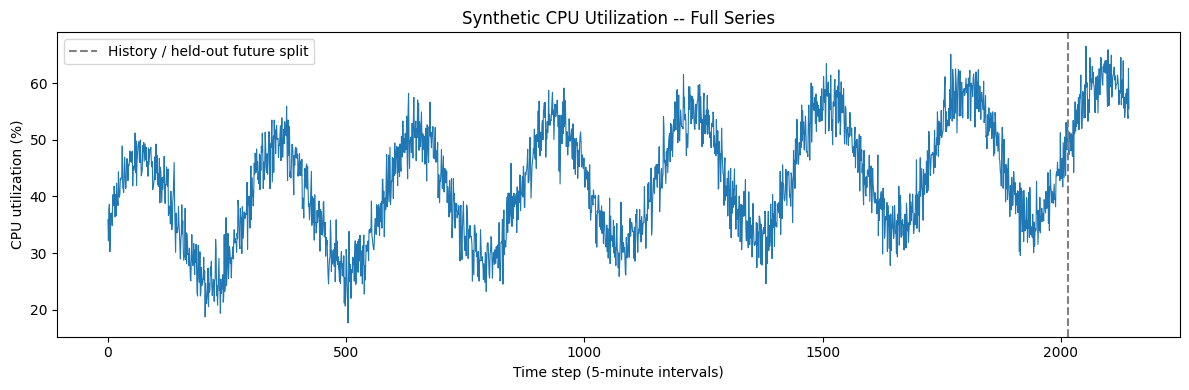

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(full_series, color="tab:blue", linewidth=0.8)
plt.axvline(history_len, color="gray", linestyle="--", label="History / held-out future split")
plt.title("Synthetic CPU Utilization -- Full Series")
plt.xlabel("Time step (5-minute intervals)")
plt.ylabel("CPU utilization (%)")
plt.legend()
plt.tight_layout()
plt.show()

## Step 4 -- Split into context and held-out future

Time series splits are chronological, never random. You cannot shuffle time and still call it forecasting -- the model must only ever see the past when predicting the future. So the first `history_len` points become the **context** CTSM is allowed to see, and the last `horizon` points become **actual_future**: the ground truth we hide from the model and compare its forecast against afterward.

Note there is no "training set" in the usual ML sense. CTSM's parameters are already fixed (pretrained by Cisco); the context is not used to update any weights, only as the conditioning input for a single forward pass. This is what "zero-shot foundation model" means in practice.

In [4]:
context = full_series[:history_len]
actual_future = full_series[history_len:]

assert len(context) == history_len
assert len(actual_future) == horizon

print(f"Context length         : {len(context)} points (what CTSM is allowed to see)")
print(f"Held-out future length : {len(actual_future)} points (what we're hiding and later grading against)")

Context length         : 2016 points (what CTSM is allowed to see)
Held-out future length : 128 points (what we're hiding and later grading against)


## Step 5 -- Run the forecast

One call: `model.forecast(context, horizon_len=128)`. Internally, CTSM converts our single-resolution context into the coarse/fine multiresolution input it was trained on, runs its transformer forward, and returns -- per input series -- a dictionary with:

- `"mean"`: the model's single best-guess forecast, one value per future step.
- `"quantiles"`: 15 percentile forecasts (from the 1st to the 99th), which express *uncertainty*. A wide gap between, say, the 10th and 90th percentile forecast means the model is unsure; a narrow gap means it's confident.

For a PM, the quantiles matter as much as the mean: a single-number forecast hides how confident the model actually is, and that confidence is exactly what should drive downstream decisions (e.g., how much safety margin to build into a capacity-planning threshold).

In [5]:
forecast = model.forecast(context, horizon_len=horizon)

forecast_mean = forecast[0]["mean"]
forecast_quantiles = forecast[0]["quantiles"]

print("forecast_mean shape:", forecast_mean.shape)
print("quantile levels    :", sorted(forecast_quantiles.keys()))

forecast_mean shape: (128,)
quantile levels    : ['0.01', '0.05', '0.1', '0.2', '0.25', '0.3', '0.4', '0.5', '0.6', '0.7', '0.75', '0.8', '0.9', '0.95', '0.99']


## Step 6 -- Plot history, actual future, and forecast together

This is the chart that actually answers "did it work?". We overlay three things on the same axis: the historical context CTSM saw, the real values that happened during the held-out window, and CTSM's forecast for that same window (mean plus a shaded 10-90% quantile band). We zoom into the last few days of context so the forecast region isn't squeezed into a sliver of the plot.

What to look for: does the red dashed line (forecast mean) track the shape of the green line (actual future) -- does it continue the upward trend and repeat the daily cycle at roughly the right phase and amplitude? Does the shaded band actually contain the green line, or does reality fall outside CTSM's own stated uncertainty?

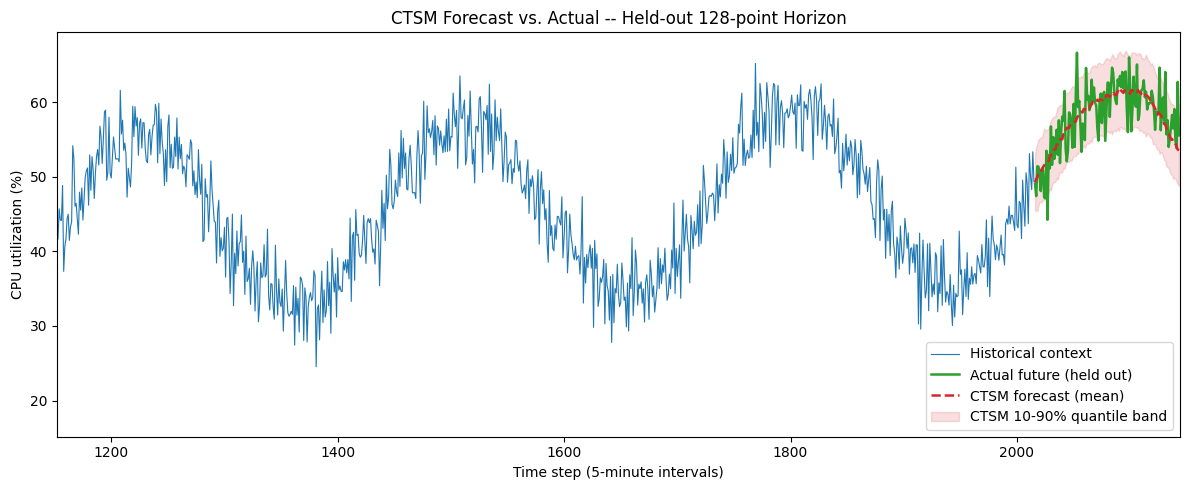

In [6]:
context_index = np.arange(0, history_len)
future_index = np.arange(history_len, total_len)

lower_band = forecast_quantiles["0.1"]
upper_band = forecast_quantiles["0.9"]

plt.figure(figsize=(12, 5))
plt.plot(context_index, context, color="tab:blue", linewidth=0.8, label="Historical context")
plt.plot(future_index, actual_future, color="tab:green", linewidth=1.8, label="Actual future (held out)")
plt.plot(future_index, forecast_mean, color="tab:red", linewidth=1.8, linestyle="--", label="CTSM forecast (mean)")
plt.fill_between(future_index, lower_band, upper_band, color="tab:red", alpha=0.15,
                  label="CTSM 10-90% quantile band")

plt.xlim(history_len - 3 * period, total_len)  # zoom to the last ~3 days of context + the forecast window
plt.title("CTSM Forecast vs. Actual -- Held-out 128-point Horizon")
plt.xlabel("Time step (5-minute intervals)")
plt.ylabel("CPU utilization (%)")
plt.legend()
plt.tight_layout()
plt.show()

## Step 7 -- Quantify accuracy: MAE and RMSE

A chart is persuasive but not precise. Two standard, easy-to-explain error metrics:

- **MAE (Mean Absolute Error)** -- average size of the miss, in the original units (percentage points of CPU). If MAE is 2.5, CTSM's forecast is off by 2.5 points of CPU utilization on average. Every error counts equally.
- **RMSE (Root Mean Squared Error)** -- same units, but squares errors before averaging (then square-roots back), so a few large misses hurt the score more than many small ones. RMSE is always >= MAE; the bigger the gap between them, the more the errors are concentrated in a few large spikes rather than spread evenly.

For an observability use case, that RMSE-vs-MAE gap is itself informative: it tells you whether the model is consistently a little off (RMSE ~ MAE) or mostly right with occasional bad misses (RMSE >> MAE) -- and the latter is the riskier failure mode for something like capacity alerting.

In [7]:
errors = forecast_mean - actual_future
mae = np.mean(np.abs(errors))
rmse = np.sqrt(np.mean(errors ** 2))

print(f"MAE  : {mae:.3f} percentage points of CPU")
print(f"RMSE : {rmse:.3f} percentage points of CPU")
print(f"RMSE / MAE ratio: {rmse / mae:.2f} (closer to 1.0 = errors spread evenly; higher = a few big misses)")

MAE  : 2.176 percentage points of CPU
RMSE : 2.854 percentage points of CPU
RMSE / MAE ratio: 1.31 (closer to 1.0 = errors spread evenly; higher = a few big misses)


## Summary and stopping point

In this notebook we: loaded CTSM zero-shot, built a synthetic CPU-utilization series with known trend + seasonality + noise, held out the last 128 points, forecast them with a single CTSM call, visualized context/actual/forecast together with an uncertainty band, and scored the forecast with MAE and RMSE.

As scoped at the top, this notebook stops here -- one clean baseline series, nothing adversarial. Deliberately deferred to a follow-up notebook: injecting anomalies/spikes, introducing missing data or gaps in the context, and stress-testing with much noisier signals, so the effect of each stressor can be isolated against this clean baseline rather than conflated together.